Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Accuracy: 0.9583333333333334
Test Accuracy : 0.8333333333333334


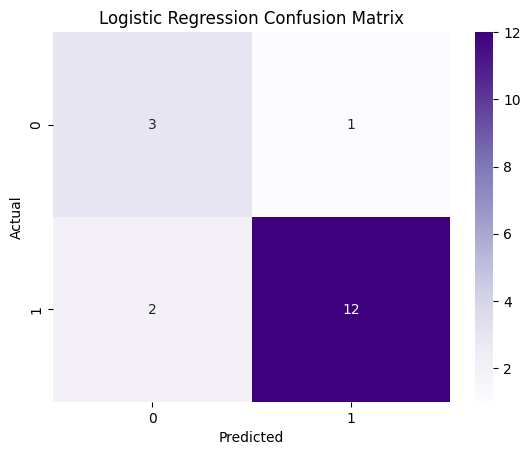

In [43]:
# LOGISTIC REGRESSION

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("/content/dataset_part_31_with_target.csv")

X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

log_cv = GridSearchCV(LogisticRegression(), params, cv=10)
log_cv.fit(X_train, Y_train)

print("Best Params:", log_cv.best_params_)

y_pred = log_cv.predict(X_test)

print("Train Accuracy:", log_cv.score(X_train, Y_train))
print("Test Accuracy :", accuracy_score(Y_test, y_pred))

cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Best Params: {'n_neighbors': 3, 'weights': 'uniform'}
Train Accuracy: 0.6666666666666666
Test Accuracy : 0.7777777777777778


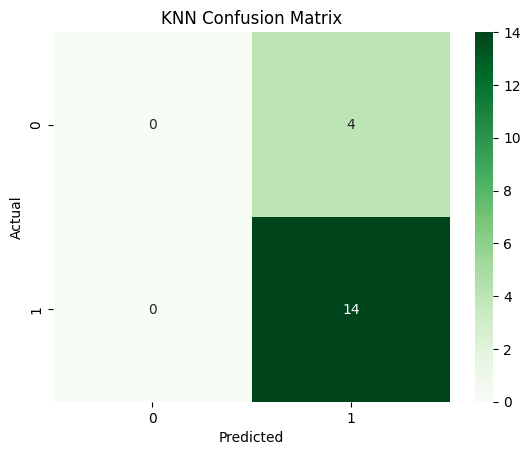

In [44]:
#KNN

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("/content/dataset_part_31_with_target.csv")

X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

knn_cv = GridSearchCV(KNeighborsClassifier(), params, cv=10)
knn_cv.fit(X_train, Y_train)

print("Best Params:", knn_cv.best_params_)

y_pred = knn_cv.predict(X_test)

print("Train Accuracy:", knn_cv.score(X_train, Y_train))
print("Test Accuracy :", accuracy_score(Y_test, y_pred))

cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Best Params: {'criterion': 'entropy', 'max_depth': 2}
Train Accuracy: 0.7339285714285714
Test Accuracy : 0.8888888888888888


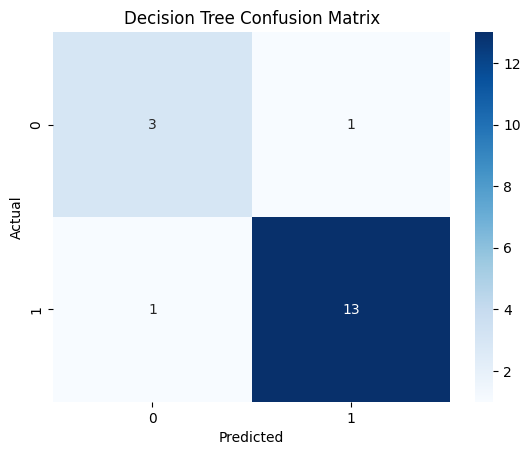

In [45]:
# DECISION TREE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("/content/dataset_part_31_with_target.csv")

X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 4, 6, 8, 10, None]
}

tree_cv = GridSearchCV(DecisionTreeClassifier(), params, cv=10)
tree_cv.fit(X_train, Y_train)

print("Best Params:", tree_cv.best_params_)

# ⭐ USE BEST ESTIMATOR TO PREDICT
best_tree = tree_cv.best_estimator_
y_pred = best_tree.predict(X_test)

# ACCURACY
print("Train Accuracy:", tree_cv.best_score_)     # CV accuracy
print("Test Accuracy :", accuracy_score(Y_test, y_pred))

# CONFUSION MATRIX
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Best Params: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Train Accuracy: 0.8888888888888888
Test Accuracy : 0.8333333333333334


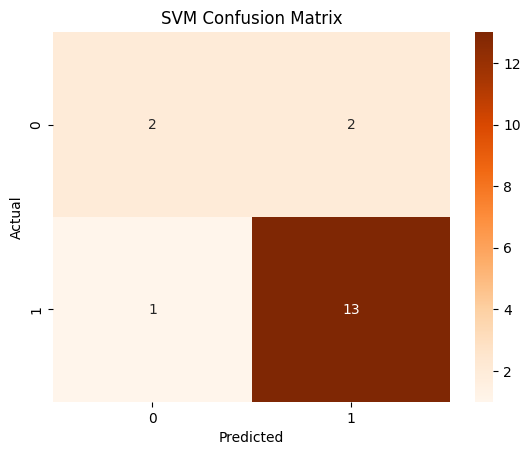

In [46]:
# SVM

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("/content/dataset_part_31_with_target.csv")

X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

svm_cv = GridSearchCV(SVC(), params, cv=10)
svm_cv.fit(X_train, Y_train)

print("Best Params:", svm_cv.best_params_)

y_pred = svm_cv.predict(X_test)

print("Train Accuracy:", svm_cv.score(X_train, Y_train))
print("Test Accuracy :", accuracy_score(Y_test, y_pred))

cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [47]:

logreg_pred = log_cv.predict(X_test)
logreg_acc = accuracy_score(Y_test, logreg_pred)


svm_pred = svm_cv.predict(X_test)
svm_acc = accuracy_score(Y_test, svm_pred)

tree_cv.fit(X_train, Y_train)

best_tree = tree_cv.best_estimator_
tree_pred = best_tree.predict(X_test)
tree_acc = accuracy_score(Y_test, tree_pred)





knn_pred = knn_cv.predict(X_test)
knn_acc = accuracy_score(Y_test, knn_pred)


accuracies = {
    "Logistic Regression": logreg_acc,
    "SVM": svm_acc,
    "Decision Tree": tree_acc,
    "KNN": knn_acc
}

print("Accuracy of each model:")
print("Logistic Regression:", logreg_acc)
print("SVM:", svm_acc)
print("Decision Tree:", tree_acc)
print("KNN:", knn_acc)

best_model = max(accuracies, key=accuracies.get)

print("\nBest performing model is:", best_model)
print("Accuracy:", accuracies[best_model])


Accuracy of each model:
Logistic Regression: 0.8333333333333334
SVM: 0.8333333333333334
Decision Tree: 0.8888888888888888
KNN: 0.7777777777777778

Best performing model is: Decision Tree
Accuracy: 0.8888888888888888
